# Question 1

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [103]:
sales = pd.read_csv("Sales_data.csv")

# check days is in running order and starts at 1
days = sales['Day']
assert days[0] == 1
assert (days == list(range(1, len(days) + 1))).all()

sales = sales.rename(columns={'Number of cupcakes sold': 'sales'})

sales['sales'].describe()

count    1095.000000
mean       49.507763
std        29.359551
min         1.000000
25%        24.000000
50%        49.000000
75%        75.000000
max       100.000000
Name: sales, dtype: float64

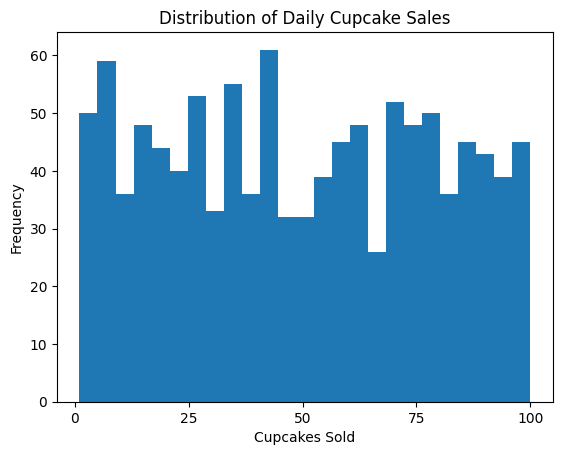

In [104]:

plt.hist(sales['sales'], bins=25)

plt.xlabel("Cupcakes Sold")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Cupcake Sales")
plt.xticks(ticks=[0,25,50,75,100])

plt.show()

## (a) Determine State Space & Compute Transition Matrix

In [105]:
sales_data = sales['sales'].values
n = len(sales_data)

states = np.array([1, 2, 3, 4])
m = len(states)
sales_idx = []
bins = [0,25,50,75,100]

for s in sales_data:
    if bins[0] <= s < bins[1]:
        sales_idx.append(0)
    elif bins[1] <= s < bins[2]:
        sales_idx.append(1)
    elif bins[2] <= s < bins[3]:
        sales_idx.append(2)
    elif bins[3] <= s <= bins[4]:
        sales_idx.append(3)

N = np.zeros((m, m))
for t in range(n - 1):
    i = sales_idx[t]
    j = sales_idx[t + 1]
    N[i, j] += 1

row_sums = N.sum(axis=1, keepdims=True)

P = np.divide(N, row_sums, out=np.zeros_like(N), where=row_sums!=0)

print("Transition Matrix:")
print(np.round(P, 4))

Transition Matrix:
[[0.308  0.2319 0.2246 0.2355]
 [0.2258 0.3047 0.2258 0.2437]
 [0.2151 0.259  0.239  0.2869]
 [0.2604 0.2257 0.2292 0.2847]]


## (b) Find Long-run distribution

In [106]:
eigvals, eigvecs = np.linalg.eig(P.T)

pi = eigvecs[:, np.isclose(eigvals,1)]
pi = pi[:,0]

pi = pi / pi.sum()
pi = pi.real

print("Stationary distribution:")
print(np.round(pi,4))

Stationary distribution:
[0.2532 0.255  0.2294 0.2623]


## (c) Find break-even cupcake price

In [107]:
states_arr = np.array([12.5,37.5,62.5,87.5])
expected_sales = np.dot(pi, states_arr)

batches = np.ceil(states_arr/12)
expected_batches = np.dot(pi, batches)

expected_cost = 5 * expected_batches + 100

price = expected_cost / expected_sales

print("Optimal price:", np.round(price, 4))

Optimal price: 2.4992


## (d) Compute past trend & expected trend in the next 3 years 

In [108]:
p = price

sales_vals = sales['sales']

batches = np.ceil(sales_vals / 12)

revenue = p * sales_vals
cost = 5 * batches + 100

profit = revenue - cost
avg_profit = profit.mean()

print("Average profit:", np.round(avg_profit, 4))

Average profit: 0.702
